# Importing necessary libraries

In [1]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

# Exploratory data analysis

## Import csv

In [2]:
profiles_ok_cupid = pd.read_csv("profiles.csv")

## Inspect the df

In [3]:
profiles_ok_cupid.head()

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,...,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
0,22,a little extra,strictly anything,socially,never,working on college/university,about me:<br />\n<br />\ni would love to think...,currently working as an international agent fo...,making people laugh.<br />\nranting about a go...,"the way i look. i am a six foot half asian, ha...",...,"south san francisco, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single
1,35,average,mostly other,often,sometimes,working on space camp,i am a chef: this is what that means.<br />\n1...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,...,"oakland, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single
2,38,thin,anything,socially,NaN,graduated from masters program,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,...,"san francisco, california",NaN,straight,has cats,NaN,m,pisces but it doesn&rsquo;t matter,no,"english, french, c++",available
3,23,thin,vegetarian,socially,NaN,working on college/university,i work in a library and go to school. . .,reading things written by old dead people,playing synthesizers and organizing books acco...,socially awkward but i do my best,...,"berkeley, california",doesn&rsquo;t want kids,straight,likes cats,NaN,m,pisces,no,"english, german (poorly)",single
4,29,athletic,NaN,socially,never,graduated from college/university,hey how's it going? currently vague on the pro...,work work work work + play,creating imagery to look at:<br />\nhttp://bag...,i smile a lot and my inquisitive nature,...,"san francisco, california",NaN,straight,likes dogs and likes cats,NaN,m,aquarius,no,english,single


###  Inspect data types and categories

In [4]:
#print data types
print(profiles_ok_cupid.dtypes)

age              int64
body_type       object
diet            object
drinks          object
drugs           object
education       object
essay0          object
essay1          object
essay2          object
essay3          object
essay4          object
essay5          object
essay6          object
essay7          object
essay8          object
essay9          object
ethnicity       object
height         float64
income           int64
job             object
last_online     object
location        object
offspring       object
orientation     object
pets            object
religion        object
sex             object
sign            object
smokes          object
speaks          object
status          object
dtype: object


In [5]:
print(len(profiles_ok_cupid))

59946


### All features are objects, except age, height and income. 
-Let's explore unique values of the object types.

In [6]:
import re

# Extract the column names
column_names = profiles_ok_cupid.columns.tolist()

# Compile a regex pattern that matches column names starting with "essay"
essay_pattern = re.compile(r"^essay")
object_column_names = []

for col in column_names:
    # Check if the dtype of the column is object 
    # and the column name does NOT start with "essay"
    if profiles_ok_cupid[col].dtype == "object" and not essay_pattern.match(col):
        object_column_names.append(col)
        print(f"{col} categories: {profiles_ok_cupid[col].unique()}")
        print(f"{col} missing values: {profiles_ok_cupid[col].isna().sum()}")
        print("----------------------------------------------------------")

body_type categories: ['a little extra' 'average' 'thin' 'athletic' 'fit' nan 'skinny' 'curvy'
 'full figured' 'jacked' 'rather not say' 'used up' 'overweight']
body_type missing values: 5296
----------------------------------------------------------
diet categories: ['strictly anything' 'mostly other' 'anything' 'vegetarian' nan
 'mostly anything' 'mostly vegetarian' 'strictly vegan'
 'strictly vegetarian' 'mostly vegan' 'strictly other' 'mostly halal'
 'other' 'vegan' 'mostly kosher' 'strictly halal' 'halal'
 'strictly kosher' 'kosher']
diet missing values: 24395
----------------------------------------------------------
drinks categories: ['socially' 'often' 'not at all' 'rarely' nan 'very often' 'desperately']
drinks missing values: 2985
----------------------------------------------------------
drugs categories: ['never' 'sometimes' nan 'often']
drugs missing values: 14080
----------------------------------------------------------
education categories: ['working on college/univers

In [7]:
profiles_ok_cupid.describe(include="object")

,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,essay4,...,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
count,54650,35551,56961,45866,53318,54458,52374,50308,48470,49409,...,59946,24385,59946,40025,39720,59946,48890,54434,59896,59946
unique,12,18,6,3,32,54350,51516,48635,43533,49260,...,199,15,3,15,45,2,48,5,7647,5
top,average,mostly anything,socially,never,graduated from college/university,.,enjoying it.,listening,my smile,ask me,...,"san francisco, california",doesn&rsquo;t have kids,straight,likes dogs and likes cats,agnosticism,m,gemini and it&rsquo;s fun to think about,no,english,single
freq,14652,16585,41780,37724,23959,12,61,82,529,16,...,31064,7560,51606,14814,2724,35829,1782,43896,21828,55697


In [8]:
#insert na values in empty cells for better handling
profiles_ok_cupid.replace("", np.nan, inplace=True)

### Conclusion
-Some features are very nuanced and need to be comined for further analysis
-Some features e.g. body type and drug consumption have a high number of missing values and are probably MNAR

### Let's explore continuous data

### Checking for missing values in the continuous data

In [9]:
#before analysis, we check for nan values
print("Null values at age:", profiles_ok_cupid.age.isna().sum())
print("Null values at height:", profiles_ok_cupid.height.isna().sum())
print("Null values at income:", profiles_ok_cupid.income.isna().sum())
#we can also check for other missing values, such as -1
print("Missing values at age:", len(profiles_ok_cupid[profiles_ok_cupid["age"] == -1]))
print("Missing values at height:", len(profiles_ok_cupid[profiles_ok_cupid["height"] == -1]))
print("Missing values at income:", len(profiles_ok_cupid[profiles_ok_cupid["income"] == -1]))

Null values at age: 0
Null values at height: 3
Null values at income: 0
Missing values at age: 0
Missing values at height: 0
Missing values at income: 48442


In [10]:
#let's inspect the na height rows
null_values = profiles_ok_cupid[profiles_ok_cupid["height"].isna()]
null_values
#other values in these rows seem to be missing as well, so I will drop these three rows
profiles_ok_cupid.dropna(subset=['height'], inplace=True)

#a lot of income values missing, but -1 disorts the results
#replacing with Na values
profiles_ok_cupid.replace(-1, np.nan, inplace=True)

In [11]:
profiles_ok_cupid.describe()

,age,height,income
count,59943.000000,59943.000000,11504.000000
mean,32.340140,68.295281,104394.993046
std,9.452723,3.994803,201433.528307
min,18.000000,1.000000,20000.000000
25%,26.000000,66.000000,20000.000000
50%,30.000000,68.000000,50000.000000
75%,37.000000,71.000000,100000.000000
max,110.000000,95.000000,1000000.000000


## Continuous data visualization

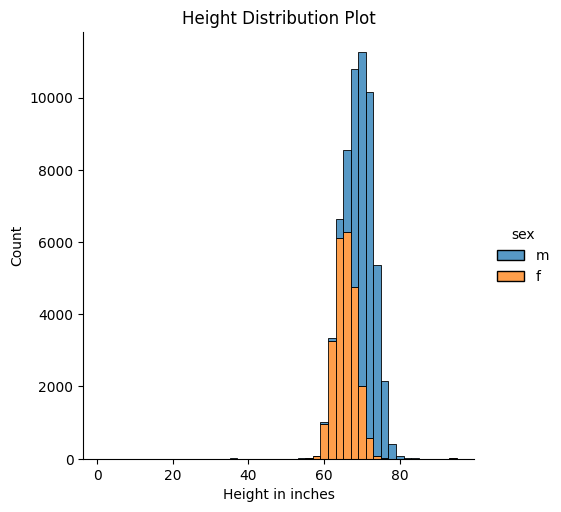

In [12]:
income = sns.displot(data=profiles_ok_cupid, x="height", kind="hist", binwidth=2, hue="sex", multiple="stack")
income.set(xlabel ="Height in inches", ylabel = "Count", title ='Height Distribution Plot')

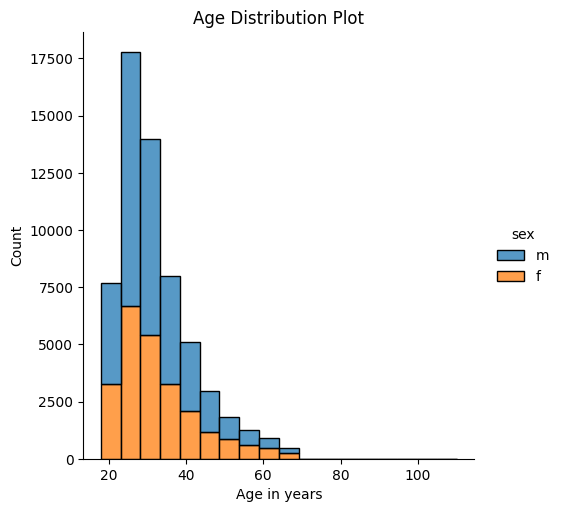

In [13]:
age = sns.displot(data=profiles_ok_cupid, x="age", kind="hist", binwidth=5, hue="sex", multiple="stack")
age.set(xlabel ="Age in years", ylabel = "Count", title ='Age Distribution Plot')

C:\Users\Aline\AppData\Local\Temp\ipykernel_3652\2305263287.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels)


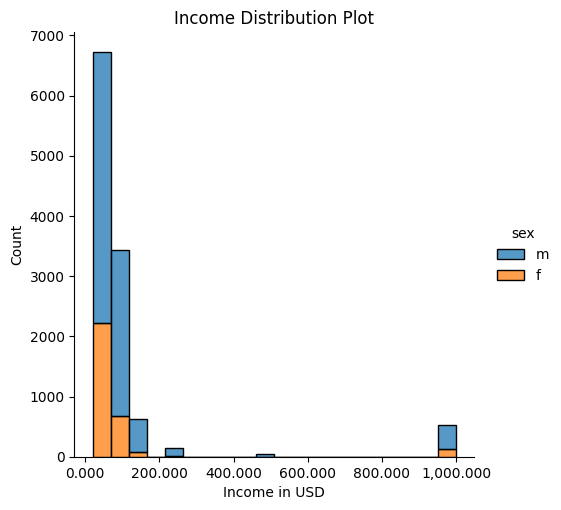

In [14]:
income = sns.displot(data=profiles_ok_cupid, x="income", kind="hist", binwidth=50000, hue="sex", multiple="stack")
income.set(xlabel ="Income in USD", ylabel = "Count", title ='Income Distribution Plot')

for ax in income.axes.flat:
    xlabels = ['{:,.3f}'.format(x) for x in ax.get_xticks()/1000]
    ax.set_xticklabels(xlabels)

<Axes: xlabel='count', ylabel='body_type'>

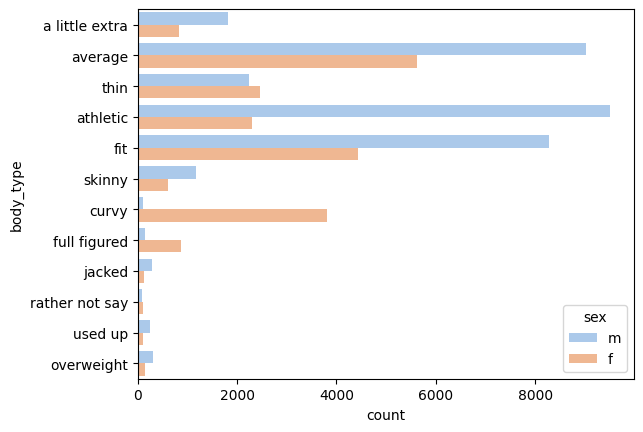

In [16]:
sns.countplot(y ='body_type', hue = "sex", data = profiles_ok_cupid, palette="pastel")

##Conclusion
- rather young people
- rather low income

### Let's visualize the categorical data

<Axes: xlabel='count', ylabel='diet'>

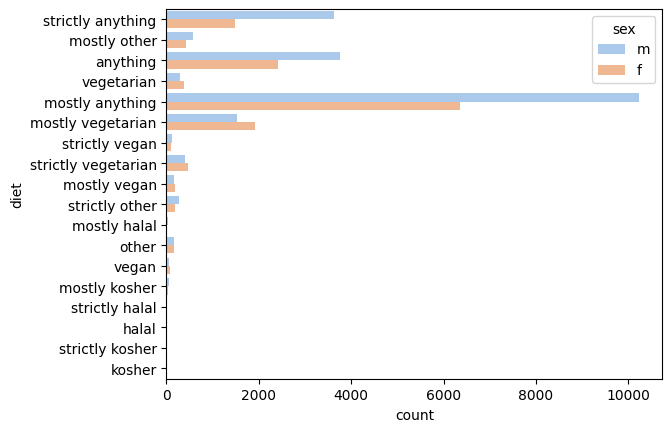

In [15]:
sns.countplot(y ='diet', hue = "sex", data = profiles_ok_cupid, palette="pastel")

<Axes: xlabel='count', ylabel='drinks'>

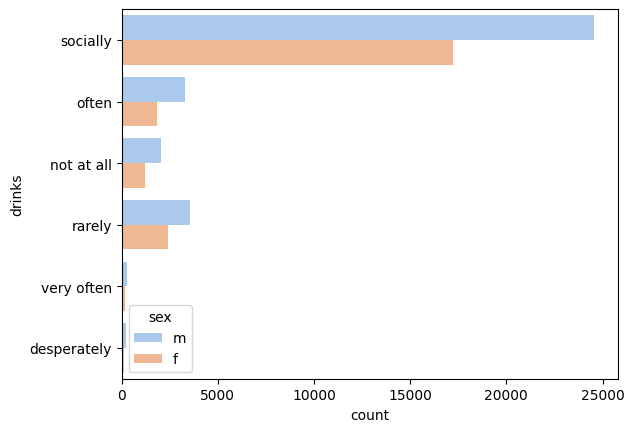

In [16]:
sns.countplot(y ='drinks', hue = "sex", data = profiles_ok_cupid, palette="pastel")

<Axes: xlabel='count', ylabel='drugs'>

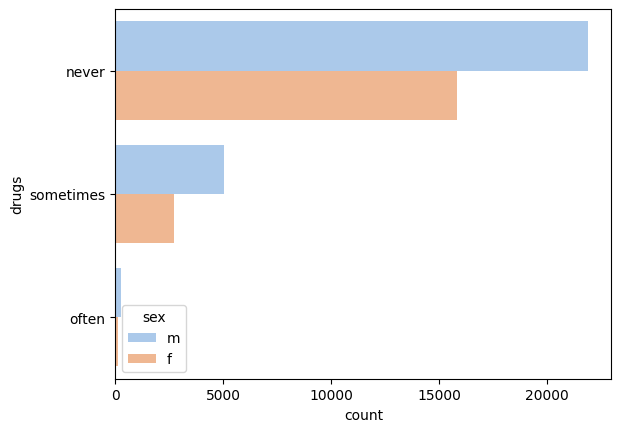

In [17]:
sns.countplot(y ='drugs', hue = "sex", data = profiles_ok_cupid, palette="pastel")

<Axes: xlabel='count', ylabel='smokes'>

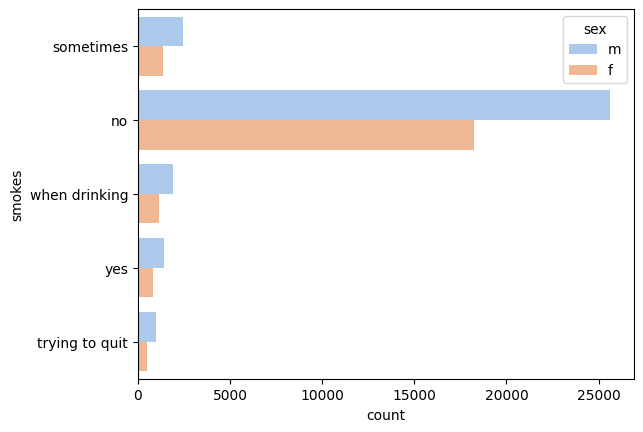

In [18]:
sns.countplot(y ='smokes', hue = "sex", data = profiles_ok_cupid, palette="pastel")

###Conclusion
- values quite imbalances, e.g. many omnivores, social drinkers, non-drug users, non-smokers 

In [26]:
#first we import the module to split the data
from sklearn.model_selection import train_test_split

#we don't want any NAs in the features or targets, so we create a new cleaned df
profiles_ok_cupid_clean = profiles_ok_cupid.dropna()

#since the data is categorical, we get dummies
profiles_ok_cupid_clean_dummies = pd.get_dummies(profiles_ok_cupid_clean[["diet", "drinks", "smokes"]])

#we want the values to be 0s and 1s and no BOOLEAN values
profiles_ok_cupid_clean_dummies = profiles_ok_cupid_clean_dummies.astype(int)
#let's have a look at the cleaned df
print(profiles_ok_cupid_clean_dummies.head())

#the features are the dummy variables of diet, drinks and smokes
x = profiles_ok_cupid_clean_dummies
print(x.head())
#the target variable is drugs
y = profiles_ok_cupid_clean["drugs"]
print(y.head())

#let's make sure we have the same amount of rows in feature and target variables
print(len(x))
print(len(y))

#now we split the data
X_train, X_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=42)

     diet_anything  diet_mostly anything  diet_mostly halal  \
94               0                     1                  0   
113              0                     1                  0   
123              0                     0                  0   
137              0                     1                  0   
167              0                     1                  0   

     diet_mostly kosher  diet_mostly other  diet_mostly vegan  \
94                    0                  0                  0   
113                   0                  0                  0   
123                   0                  0                  0   
137                   0                  0                  0   
167                   0                  0                  0   

     diet_mostly vegetarian  diet_other  diet_strictly anything  \
94                        0           0                       0   
113                       0           0                       0   
123                       0  

### Now we initialize a Decision Tree and fit it

0.7368421052631579


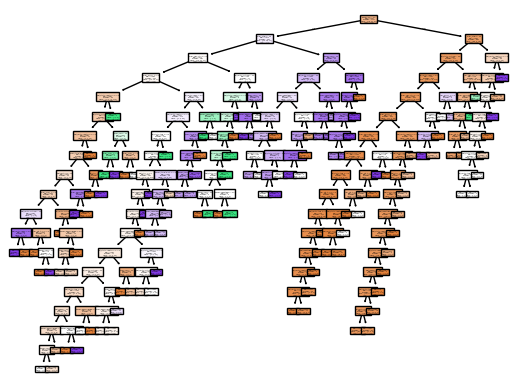

In [28]:
#gettint the decision tree classifier and module to plot it
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Fit grid search on training data
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
print(clf.score(X_test, y_test))

plot_tree(clf, feature_names=x.columns, class_names=['never', 'sometimes', 'often'], filled=True)
plt.show()

### We can probably boost the accuracy of this model by using a random forrest classifier

In [29]:
#getting necessary modules
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

#initialization
rfc = RandomForestClassifier(random_state=42)

#creating a param-grid so we can compare different parameter values
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

#now we do a cross-fold grid search
grid_search = GridSearchCV(rfc, param_grid, cv=5, scoring='accuracy')

# Fit grid search on training data
grid_search.fit(X_train, y_train)

#now we can get the best parameter values and accuracy when using this values (on the validation set)
print("Best max_depth:", grid_search.best_params_['max_depth'])
print("Best cross-validated accuracy:", grid_search.best_score_)

C:\Users\Aline\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best max_depth: 15
Best cross-validated accuracy: 0.7278112682587526


In [30]:
#printing out the best parameter values
print(grid_search.best_params)

{'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}


In [33]:
#evaluation on the test data
# Directly use the best model found by GridSearchCV
best_model = grid_search.best_estimator_

# Evaluate it on the test set
test_accuracy = best_model.score(X_test, y_test)
print(f"Test Accuracy: {test_accuracy}")

Test Accuracy: 0.7614035087719299


### Conclusion
- the random forest shows higher accuracy than the random forest

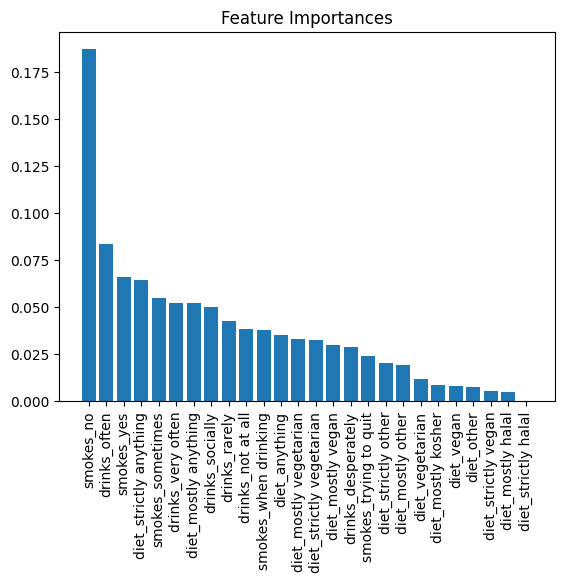

In [34]:
feature_importances = rfc.feature_importances_
indices = np.argsort(feature_importances)[::-1]
plt.bar(range(len(feature_importances)), feature_importances[indices])
plt.xticks(range(len(feature_importances)), np.array(x.columns)[indices], rotation=90)
plt.title("Feature Importances")
plt.show()

#Conclusion
- most of the diet features don't have a high importance score

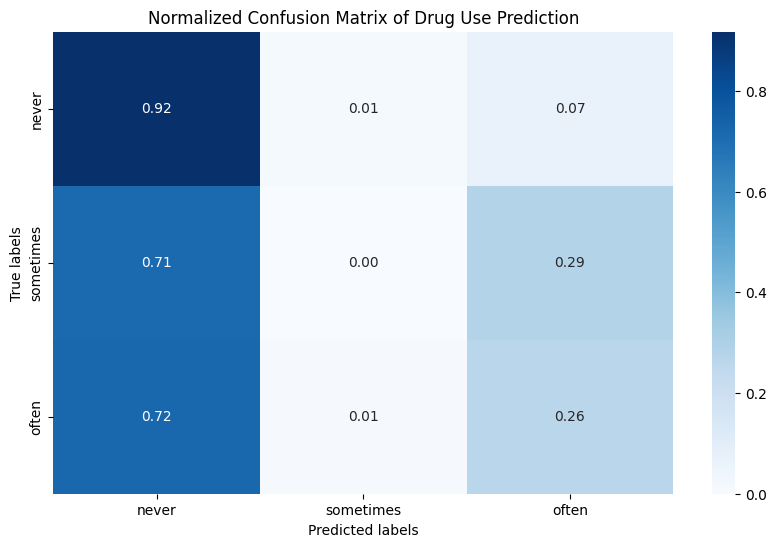

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
y_pred = rfc.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Normalize confusion matrix by dividing by the total number of instances
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot normalized confusion matrix
plt.figure(figsize=(10, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=['never', 'sometimes', 'often'], yticklabels=['never', 'sometimes', 'often'])
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title("Normalized Confusion Matrix of Drug Use Prediction")
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Get predictions
y_pred = rfc.predict(X_test)

# Print classification report for multiclass classification
print(classification_report(y_test, y_pred, target_names=['Class 1', 'Class 2', 'Class 3']))

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 1', 'Class 2', 'Class 3'], yticklabels=['Class 1', 'Class 2', 'Class 3'])
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title("Confusion Matrix for Multiclass Classification")
plt.show()
